# Geological Lithology Prediction using Machine Learning
Author: Okafor Victor Arinze

This project demonstrates lithology classification using synthetic well log data.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set(style="whitegrid")

In [5]:
np.random.seed(42)
n_samples = 500

data = {
    "Gamma_Ray": np.random.uniform(20,150,n_samples),
    "Resistivity": np.random.uniform(10,1000,n_samples),
    "Porosity": np.random.uniform(0.05,0.30,n_samples),
    "Density": np.random.uniform(2.0,3.0,n_samples)
}

df = pd.DataFrame(data)
df.head()


,Gamma_Ray,Resistivity,Porosity,Density
0,68.690215,701.180097,0.096283,2.519082
1,143.592860,540.735403,0.185475,2.479182
2,115.159212,316.432340,0.268236,2.025642
3,97.825603,815.657070,0.233056,2.341248
4,40.282423,687.883861,0.251640,2.380196


In [6]:
# Create lithology labels from simple geological rules
conditions = [
    (df["Gamma_Ray"] > 100) & (df["Porosity"] < 0.15),   # Shale
    (df["Gamma_Ray"] < 60) & (df["Resistivity"] > 500)   # Limestone
]
choices = [1, 2]  # 1=Shale, 2=Limestone

df["Lithology"] = np.select(conditions, choices, default=0)  # default Sandstone

lithology_map = {0: "Sandstone", 1: "Shale", 2: "Limestone"}
df["Lithology_Name"] = df["Lithology"].map(lithology_map)

df[["Gamma_Ray","Resistivity","Porosity","Density","Lithology_Name"]].head()

,Gamma_Ray,Resistivity,Porosity,Density,Lithology_Name
0,68.690215,701.180097,0.096283,2.519082,Sandstone
1,143.592860,540.735403,0.185475,2.479182,Sandstone
2,115.159212,316.432340,0.268236,2.025642,Sandstone
3,97.825603,815.657070,0.233056,2.341248,Sandstone
4,40.282423,687.883861,0.251640,2.380196,Limestone


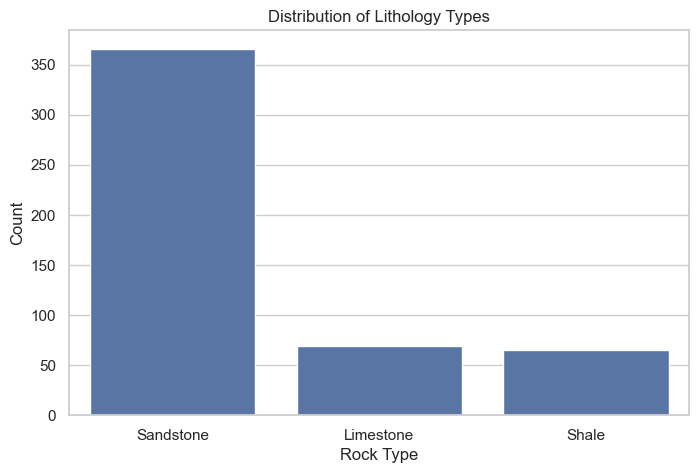

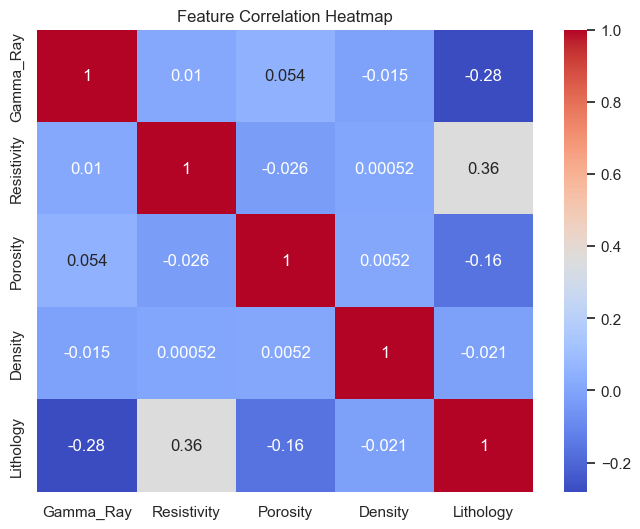

In [7]:
# Plot lithology distribution
plt.figure(figsize=(8,5))
sns.countplot(x="Lithology_Name", data=df)
plt.title("Distribution of Lithology Types")
plt.xlabel("Rock Type")
plt.ylabel("Count")
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,6))
corr = df[["Gamma_Ray","Resistivity","Porosity","Density","Lithology"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [8]:
# Prepare features and target
X = df[["Gamma_Ray","Resistivity","Porosity","Density"]]
y = df["Lithology"]

# Train/test split (stratify keeps class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train a Random Forest classifier
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

print("Model trained.")

Model trained.


Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

   Sandstone       1.00      1.00      1.00        73
       Shale       1.00      1.00      1.00        13
   Limestone       1.00      1.00      1.00        14

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



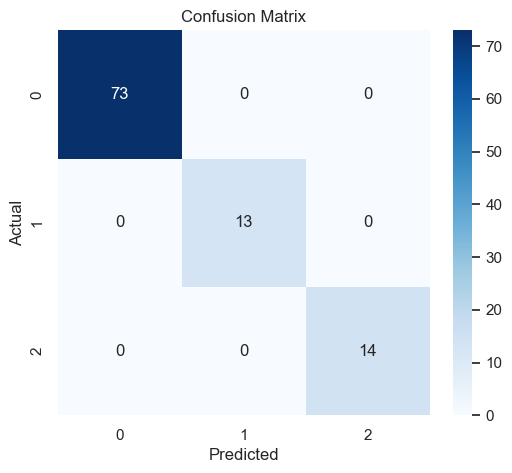

In [9]:
# Predictions
y_pred = model.predict(X_test)

# Accuracy + report
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Sandstone","Shale","Limestone"]))

# Confusion matrix plot
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

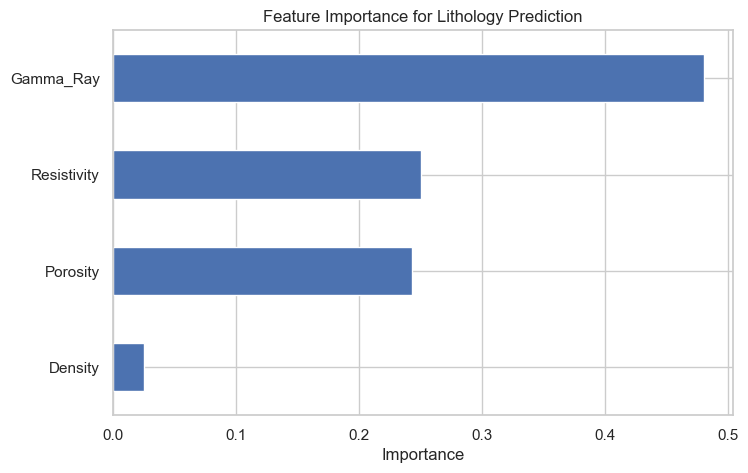

Density        0.025275
Porosity       0.243501
Resistivity    0.250749
Gamma_Ray      0.480475
dtype: float64

In [10]:
# Feature importance (interpretability)
feature_importance = pd.Series(model.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8,5))
feature_importance.plot(kind="barh")
plt.title("Feature Importance for Lithology Prediction")
plt.xlabel("Importance")
plt.show()

feature_importance